In [4]:
import torchdrug
print(torchdrug.__version__)


0.2.1


In [5]:
%matplotlib inline


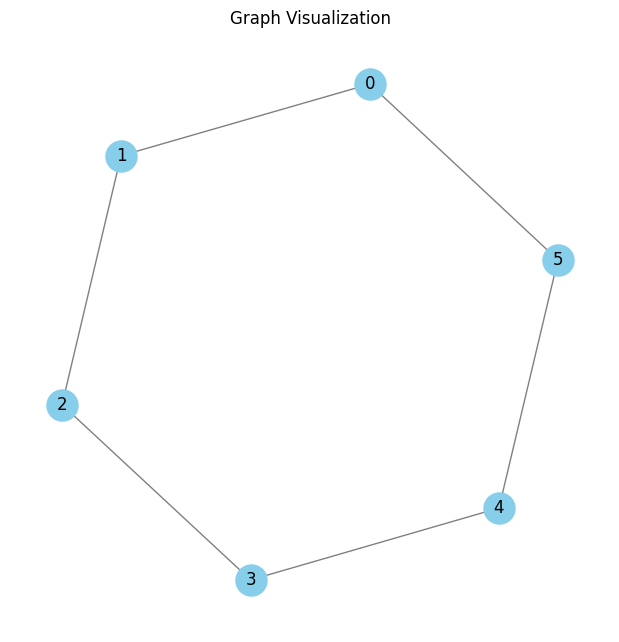

In [6]:
import torchdrug as td
from torchdrug import data
import matplotlib.pyplot as plt
import networkx as nx

# Ensure Matplotlib displays plots inside Jupyter Notebook
%matplotlib inline  

# Define the edges of the graph
edge_list = [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 0]]

# Convert the edge list to a NetworkX graph
nx_graph = nx.Graph()
nx_graph.add_edges_from(edge_list)

# Draw the graph using Matplotlib
plt.figure(figsize=(6, 6))
nx.draw(nx_graph, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=12)
plt.title("Graph Visualization")
plt.show()


In [7]:
import torchdrug as td
from torchdrug import data, utils

pdb_file = utils.download("https://files.rcsb.org/download/2LWZ.pdb", "./")
protein = data.Protein.from_pdb(pdb_file, atom_feature="position", bond_feature="length", residue_feature="symbol")
print(protein)

12:52:54   Downloading https://files.rcsb.org/download/2LWZ.pdb to ./2LWZ.pdb
Protein(num_atom=445, num_bond=916, num_residue=57)


In [8]:
conda install -c conda-forge nglview


Channels:
 - conda-forge
 - defaults
 - pytorch
Platform: osx-64
doneecting package metadata (repodata.json): - 
doneing environment: - 

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [11]:
import nglview
print("nglview is installed and working!")


nglview is installed and working!


In [12]:
from rdkit import Chem
import nglview

protein.to_pdb("new_2LWZ.pdb")
mol = Chem.MolFromPDBFile("new_2LWZ.pdb")
view = nglview.show_rdkit(mol)
view

NGLWidget()

In [13]:
import nglview as nv
from rdkit import Chem

# Load and visualize a protein PDB file
view = nv.show_file("new_2LWZ.pdb")  # Replace with your PDB file path if different
view


NGLWidget()

In [14]:
aa_seq = protein.to_sequence()
print(aa_seq)
seq_protein = data.Protein.from_sequence(aa_seq, atom_feature="symbol", bond_feature="length", residue_feature="symbol")
print(seq_protein)

FVNQHLCGSDLVEALYLVCGERGFFYTDPTGGGPRRGIVEQCCHSICSLYQLENYCN
Protein(num_atom=445, num_bond=910, num_residue=57)


In [14]:
import torch
print(torch.cuda.is_available())  # Should print True if CUDA is enabled


False


In [15]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch
print(torch.backends.mps.is_available())  # Should print True


True


In [20]:
import torch
from torchdrug import data

# Force using CPU since TorchDrug does not support MPS (Apple GPU)
device = torch.device("cpu")

# Define a sample protein sequence
sequence = "MKTLLILTCLVAVALARPK"

# Create a Protein object from the sequence
protein = data.Protein.from_sequence(sequence)

# Create a batch of proteins
proteins = [protein] * 3
proteins = data.Protein.pack(proteins)

# Move to CPU (TorchDrug does NOT support MPS)
proteins = proteins.cpu()

print(proteins)



PackedProtein(batch_size=3, num_atoms=[142, 142, 142], num_bonds=[284, 284, 284], num_residues=[19, 19, 19])


In [40]:
import nglview as nv

# Load a real PDB structure from the Protein Data Bank
view = nv.show_pdbid("2LWZ")  # Replace "2LWZ" with any valid PDB ID
view


NGLWidget()